In [1]:
!pip install tiktoken tqdm matplotlib

Devices: [CudaDevice(id=0), CudaDevice(id=1)]
Config: L=8, D=128, ffn=256, Vocab=50263


100%|██████████| 12001/12001 [4:23:59<00:00,  1.32s/it, loss=4.1342, lr=0.0005446]


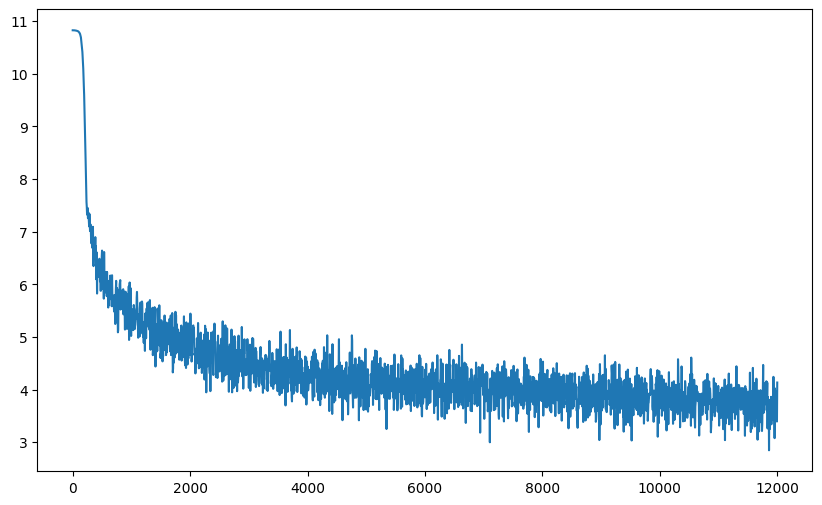

In [2]:
import jax
import jax.numpy as jnp
from jax import jit, vmap, lax, config
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
from jax.experimental import mesh_utils
import optax
import numpy as np
import tiktoken
import os
from tqdm import tqdm
from functools import partial
import matplotlib.pyplot as plt

config_layers = 8
config_heads = 8
config_dims = 128
config_d_h = 16
config_seq_len = 256
config_batch_size = 16
config_accum_size = 1
config_steps = 12000
config_lr = 12e-4
config_rope_base = 10000
config_ffn_mult = 2
config_initial_retention = 0.95
config_sinus = True

config_tpu = True

# for resuming dead sessions
config_is_continuing = False
config_continue_point = None
config_continue_steps = 0

if (config_dims / config_heads) != config_d_h:
    print("bad config, things will go wrong: (dims / heads) != d_h")
if config_is_continuing and not config_continue_point:
    print("bad config, things will go wrong: is_continuing && !continue_point")
if config_layers != config_heads:
    print("inadvisable config, things may go wrong: layers != heads")
if (config_batch_size * config_accum_size) != 16:
    print("inadvisable config, things may go wrong: batch_size * accum_size != 16")

devices = None

if config_tpu:
    devices = mesh_utils.create_device_mesh((jax.device_count(),))

os.environ["JAX_DEFAULT_DTYPE_BITS"] = "32"
config.update("jax_enable_x64", False)
config.update("jax_default_matmul_precision", "high")

print(f"Devices: {jax.devices()}")

os.makedirs("/kaggle/working/", exist_ok=True)
os.makedirs("/kaggle/temp/", exist_ok=True)

_rope_inv_freq = 1.0 / (config_rope_base ** (jnp.arange(0, config_d_h, 2) / config_d_h))

def r_norm(x, scale, eps=1e-4):
    normed = x * jax.lax.rsqrt(jnp.mean(jnp.square(x), axis=-1, keepdims=True) + eps)
    return normed * scale

def swiglu(x, params, s):
    gate = jnp.dot(x, params['W_swi_gate' + s])
    val  = jnp.dot(x, params['W_swi_val'  + s])
    return jnp.dot(jax.nn.silu(gate) * val, params['W_swi_out' + s])


def apply_rope(x, pos):
    t = pos * _rope_inv_freq
    c, s = jnp.cos(t), jnp.sin(t)
    D = x.shape[-1]
    return jnp.concatenate([
        x[..., :D // 2] * c - x[..., D // 2:] * s,
        x[..., :D // 2] * s + x[..., D // 2:] * c,
    ], axis=-1)


def cell_gates(params, x, pos, l, num_heads, d_h):
    s  = f'_l{l}'
    xn = r_norm(x, params[f'norm_pre{s}'])
    
    q_a = jax.nn.softplus(jnp.dot(xn, params['W_qa' + s])).reshape(num_heads, d_h)
    q_b = jax.nn.softplus(jnp.dot(xn, params['W_qb' + s])).reshape(num_heads, d_h)
    k1  = jax.nn.softplus(jnp.dot(xn, params['W_k1' + s])).reshape(num_heads, d_h)
    k2  = jax.nn.softplus(jnp.dot(xn, params['W_k2' + s])).reshape(num_heads, d_h)
    v   = jnp.dot(xn, params['W_v' + s]).reshape(num_heads, d_h)
    q_a, k1 = apply_rope(q_a, pos), apply_rope(k1, pos)

    gamma      = jnp.exp(-jnp.exp(params['gamma'      + s]))
    gamma_fast = jnp.exp(-jnp.exp(params['gamma_fast' + s]))

    f3 = (jax.nn.sigmoid(jnp.dot(xn, params['W_f' + s]) + params['b_f' + s]) * gamma
          ).reshape(num_heads, 1)
    f2 = gamma_fast.reshape(num_heads, 1, 1)
    ig = jax.nn.sigmoid(jnp.dot(xn, params['W_i' + s]) + params['b_i' + s]
                        ).reshape(num_heads, 1, 1, 1)
    r_t = jax.nn.sigmoid(
        jnp.dot(xn, params['W_r' + s]) + params['b_r' + s]
    ).reshape(num_heads, 1)

    u3 = vmap(lambda _k1, _k2, _v: jnp.reshape(jnp.outer(_k1, _k2), (d_h, d_h, 1)) * _v
              )(k1, k2, v)
    u2 = vmap(jnp.outer)(k1, v)

    iu3_flat = (ig * r_t[..., None, None] * u3).reshape(num_heads, d_h * d_h * d_h)
    u2       = (1.0 - r_t)[..., None] * u2
    return q_a, q_b, f3, iu3_flat, f2, u2


@partial(jit, static_argnames=['L_count', 'num_heads', 'd_h', 'training'])
def model_forward(params, X, Y=None, L_count=4, num_heads=4, d_h=16, training=True):
    B, N  = X.shape
    curr  = params['embed'][X]
    positions = jnp.arange(N)

    for l in range(L_count):
        s     = f'_l{l}'
        x_seq = curr.transpose(1, 0, 2)

        def get_gates(x_t, pos):
            return vmap(lambda x: cell_gates(params, x, pos, l, num_heads, d_h))(x_t)

        all_qa, all_qb, all_f3, all_iu3, all_f2, all_u2 = vmap(get_gates)(x_seq, positions)

        def combine(a, b):
            (fa3, ha3), (fa2, ha2) = a
            (fb3, hb3), (fb2, hb2) = b
            return (fa3 * fb3, fb3 * ha3 + hb3), (fa2 * fb2, fb2 * ha2 + hb2)

        (_, all_h3), (_, all_h2) = jax.lax.associative_scan(
            combine,
            ((all_f3, all_iu3), (all_f2, all_u2)),
            axis=0,
        )

        def readout(q_a, q_b, h3_flat, h2):
            h3 = h3_flat.reshape(num_heads, d_h, d_h, d_h)
            r3 = vmap(lambda _qa, _qb, _h:
                      jnp.dot(_qb, jnp.tensordot(_qa, _h, axes=([0], [0])))
                     )(q_a, q_b, h3)
            r2 = vmap(jnp.dot)(q_a, h2)
            y  = jnp.dot((r3 + r2).reshape(-1), params['W_p' + s]) + params['b_p' + s]
            return swiglu(y, params, s)

        layer_out = vmap(vmap(readout))(all_qa, all_qb, all_h3, all_h2).transpose(1, 0, 2)
        curr      = r_norm(curr + layer_out, params[f'norm_post{s}'])
        
    if training and Y is not None:
        curr_out = r_norm(curr, params['norm_final'])
        tw  = params['W_out'][:, Y].transpose(1, 2, 0)
        tl  = jnp.sum(curr_out * tw, axis=-1) + params['b_out'][Y]
        lse = vmap(vmap(
            lambda lat: jax.nn.logsumexp(jnp.dot(lat, params['W_out']) + params['b_out'])
        ))(curr_out)
        return tl - lse
    curr_out = r_norm(curr, params['norm_final'])
    return jnp.matmul(curr_out, params['W_out']) + params['b_out']


def generate(params, enc, L_count=4, num_heads=4, d_h=16,
             seed="<|user|>\nHello, who are you?\n<|assistant|>\n",
             length=150, temperature=0.7):
    tokens = enc.encode_ordinary(seed)

    h3  = [jnp.zeros((1, num_heads, d_h * d_h * d_h)) for _ in range(L_count)]
    h2  = [jnp.zeros((1, num_heads, d_h, d_h))         for _ in range(L_count)]
    key = jax.random.PRNGKey(42)
    pos = 0

    def step(x):
        nonlocal h3, h2
        for l in range(L_count):
            s = f'_l{l}'
            qa_b, qb_b, f3_b, iu3_b, f2_b, u2_b = vmap(
                lambda _x: cell_gates(params, _x, pos, l, num_heads, d_h)
            )(x)
    
            h3[l] = f3_b * h3[l] + iu3_b
            h2[l] = f2_b * h2[l] + u2_b
    
            h3_unflat = h3[l][0].reshape(num_heads, d_h, d_h, d_h)
    
            r3 = vmap(lambda _qa, _qb, _h:
                      jnp.dot(_qb, jnp.tensordot(_qa, _h, axes=([0], [0])))
                     )(qa_b[0], qb_b[0], h3_unflat)
            r2 = vmap(jnp.dot)(qa_b[0], h2[l][0])
    
            y        = jnp.dot((r3 + r2).reshape(-1), params['W_p' + s]) + params['b_p' + s]
            layer_out = swiglu(y, params, s)
            x        = r_norm(x + layer_out[None], params[f'norm_post{s}'])
        return x

    for t in tokens:
        step(params['embed'][jnp.array([t])])
        pos += 1

    res = list(tokens)
    ct  = tokens[-1]
    for _ in range(length):
        x       = step(params['embed'][jnp.array([ct])])
        x_out   = r_norm(x[0], params['norm_final'])
        logits  = jnp.dot(x_out, params['W_out']) + params['b_out']
        key, sk = jax.random.split(key)
        ct = int(jax.random.categorical(
            sk, jnp.log(jax.nn.softmax(logits / temperature) + 1e-10)
        ))
        res.append(ct)
        pos += 1

    return enc.decode([t for t in res if t < 50257])


def create_compiled_get_batch(data, seq_len, batch_size, sharding):
    num_tokens = len(data) - seq_len

    if config_tpu and sharding:
        @jit
        def get_batch(key):
            ix = jax.random.randint(key, (batch_size,), 0, num_tokens)
            x  = vmap(lambda i: lax.dynamic_slice(data, (i,),     (seq_len,)))(ix)
            y  = vmap(lambda i: lax.dynamic_slice(data, (i + 1,), (seq_len,)))(ix)
            x  = jax.device_put(x, sharding)
            y  = jax.device_put(y, sharding)
            return x, y
    else:
        @jit
        def get_batch(key):
            ix = jax.random.randint(key, (batch_size,), 0, num_tokens)
            x  = vmap(lambda i: lax.dynamic_slice(data, (i,),     (seq_len,)))(ix)
            y  = vmap(lambda i: lax.dynamic_slice(data, (i + 1,), (seq_len,)))(ix)
            return x, y

    return get_batch


def create_compiled_accum_step(train_step, get_batch, accum_steps):
    @jit
    def accum_step(params, opt_state, key):
        def body(carry, _):
            key, params, opt_state, grad_acc = carry
            key, subkey = jax.random.split(key)
            bx, by = get_batch(subkey)
            loss, grads = train_step(params, bx, by)
            grad_acc = jax.tree.map(lambda g, ga: ga + g, grads, grad_acc)
            return (key, params, opt_state, grad_acc), loss

        grad_acc = jax.tree.map(jnp.zeros_like, params)
        (key, params, opt_state, grad_acc), losses = lax.scan(
            body, (key, params, opt_state, grad_acc), None, length=accum_steps
        )
        return jnp.mean(losses), jax.tree.map(lambda g: g / accum_steps, grad_acc), key, params, opt_state

    return accum_step


def train_v2():
    L       = config_layers
    D_res   = config_dims
    heads   = config_heads
    d_h     = config_d_h
    v_size  = 50263
    ffn_dim = D_res * config_ffn_mult

    data = np.fromfile(
        "/kaggle/input/datasets/arm64be/netrunner-pre-training-v1/pretrain.bin",
        dtype=np.uint16,
    ).astype(np.int32)
    data = jnp.array(data)

    k = jax.random.PRNGKey(42)

    def init_params(key):
        scale      = float(0.01)
        gamma_init = float(jnp.log(-jnp.log(1.0 - config_initial_retention)))
        gfast_init = float(jnp.log(-jnp.log(1.0 - 0.5)))
        bias_open  =  float(jnp.log(max(heads - 1.0, 1.0)))
        bias_close = -float(jnp.log(max(heads - 1.0, 1.0)))
        nf         = heads * d_h

        p = {'embed': jax.random.normal(key, (v_size, D_res)) * scale}
        for l in range(L):
            s = f'_l{l}'
            p[f'W_qa{s}'] = jax.random.normal(key, (D_res, nf)) * scale
            p[f'W_qb{s}'] = jax.random.normal(key, (D_res, nf)) * scale
            p[f'W_k1{s}']       = jax.random.normal(key, (D_res, nf))      * scale
            p[f'W_k2{s}']       = jax.random.normal(key, (D_res, nf))      * scale
            p[f'W_v{s}']        = jax.random.normal(key, (D_res, nf))      * scale
            p[f'W_f{s}']        = jax.random.normal(key, (D_res, heads))   * scale
            p[f'b_f{s}']        = jnp.full((heads,), bias_open)
            p[f'W_i{s}']        = jax.random.normal(key, (D_res, heads))   * scale
            p[f'b_i{s}']        = jnp.full((heads,), bias_close)
            p[f'gamma{s}']      = jnp.full((heads,), gamma_init)
            p[f'gamma_fast{s}'] = jnp.full((heads,), gfast_init)
            p[f'W_p{s}']        = jax.random.normal(key, (nf, D_res))      * scale
            p[f'b_p{s}']        = jnp.zeros((D_res,))
            p[f'W_swi_gate{s}'] = jax.random.normal(key, (D_res, ffn_dim)) * scale
            p[f'W_swi_val{s}']  = jax.random.normal(key, (D_res, ffn_dim)) * scale
            p[f'W_swi_out{s}']  = jax.random.normal(key, (ffn_dim, D_res)) * scale
            p[f'norm_pre{s}'] = jnp.ones((D_res,))
            p[f'norm_post{s}'] = jnp.ones((D_res,))
            p[f'W_r{s}'] = jax.random.normal(key, (D_res, heads)) * scale
            p[f'b_r{s}'] = jnp.zeros((heads,))
        p['W_out'] = jax.random.normal(key, (D_res, v_size)) * scale
        p['b_out'] = jnp.zeros((v_size,))
        p['norm_final'] = jnp.full((D_res,), 0.01)
        return p

    params     = init_params(k)
    start_step = 0

    if config_is_continuing and config_continue_point and os.path.exists(config_continue_point):
        print(f"Continuing from {config_continue_point}")
        with open(config_continue_point, 'rb') as f:
            params = np.load(f, allow_pickle=True).item()
        start_step = int(config_continue_steps)
        print(f"Skipping to step: {start_step}")

    sharding = None

    warmup    = int(config_steps * 0.1)
    lr_sched  = optax.warmup_cosine_decay_schedule(1e-7, config_lr, warmup, (config_steps - warmup) * 2)
    optimizer = optax.chain(optax.adabelief(lr_sched))
    opt_state = optimizer.init(params)

    if config_tpu:
        mesh      = Mesh(devices, axis_names=('batch',))
        replicated = NamedSharding(mesh, P())
        sharding   = NamedSharding(mesh, P('batch'))
        params     = jax.device_put(params, replicated)
        opt_state  = jax.device_put(opt_state, replicated)

    get_batch  = create_compiled_get_batch(data, config_seq_len, config_batch_size, sharding)

    @jit
    def train_step(p, bx, by):
        def loss_fn(p_in):
            ll = model_forward(p_in, bx, by, L_count=L, num_heads=heads, d_h=d_h, training=True)
            return -jnp.mean(ll)
        return jax.value_and_grad(loss_fn)(p)

    accum_step = create_compiled_accum_step(train_step, get_batch, accum_steps=config_accum_size)

    print(f"Config: L={L}, D={D_res}, ffn={ffn_dim}, Vocab={v_size}")
    loss_history = []
    pbar = tqdm(range(start_step, config_steps + 1))

    for curr_step in pbar:
        loss, grads, k, params, opt_state = accum_step(params, opt_state, k)

        if config_sinus:
            def make_multiplier(path, _):
                key_str = str(path)
                for l_idx in range(config_layers):
                    if f'_l{l_idx}' in key_str and "norm" not in key_str and "gamma" not in key_str and "swi" not in key_str:
                        angle = (l_idx / config_layers) * 2 * jnp.pi
                        omega = 2 * jnp.pi / 1000
                        return 0.9 + 0.5 * jnp.sin(curr_step * omega + angle)
                return 1.0

            multipliers = jax.tree_util.tree_map_with_path(make_multiplier, grads)
            grads = jax.tree.map(lambda g, m: g * m, grads, multipliers)

        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)

        if curr_step % 250 == 0 or curr_step == config_steps:
            ckpt_p = f"/kaggle/working/checkpoint_{curr_step}.npy"
            with open(ckpt_p, 'wb') as f:
                np.save(f, jax.device_get(params))

        pbar.set_postfix({"loss": f"{loss:.4f}", "lr": f"{lr_sched(curr_step):.7f}"})
        if curr_step % 5 == 0:
            loss_history.append((curr_step, float(loss)))

    st, ls = zip(*loss_history)
    plt.figure(figsize=(10, 6))
    plt.plot(st, ls)
    plt.savefig("/kaggle/working/loss_graph.png")


if __name__ == "__main__":
    train_v2()

In [3]:
!ls -lth /kaggle/temp/

total 0


/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [4]:
cp /kaggle/temp/checkpoint_4000.npy /kaggle/working/

cp: cannot stat '/kaggle/temp/checkpoint_4000.npy': No such file or directory
